# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Python/Data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [21]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

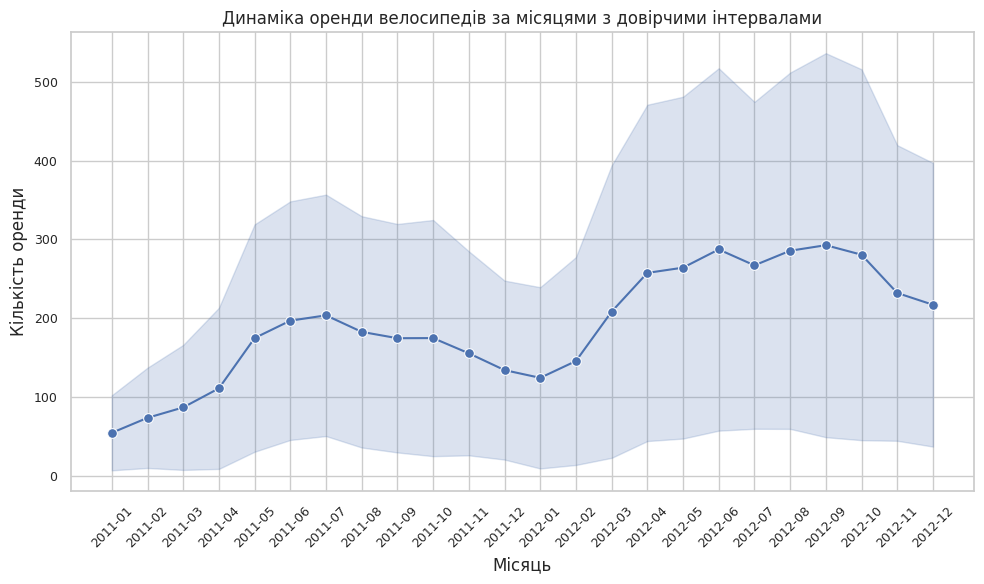

In [23]:
plt.figure(figsize=(10, 6))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o', markersize=7)
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout();

Найбільша невизначеність в даних спостерігається в періоді серпень-вересень 2012, тому що розрив між верхньою та нижньою межами найбільший саме в цьому періоді. В ці місяці значення кількості оренд найбільше варіювалися, тому середнє значення менш точно характеризує всі спостереження за місяць.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

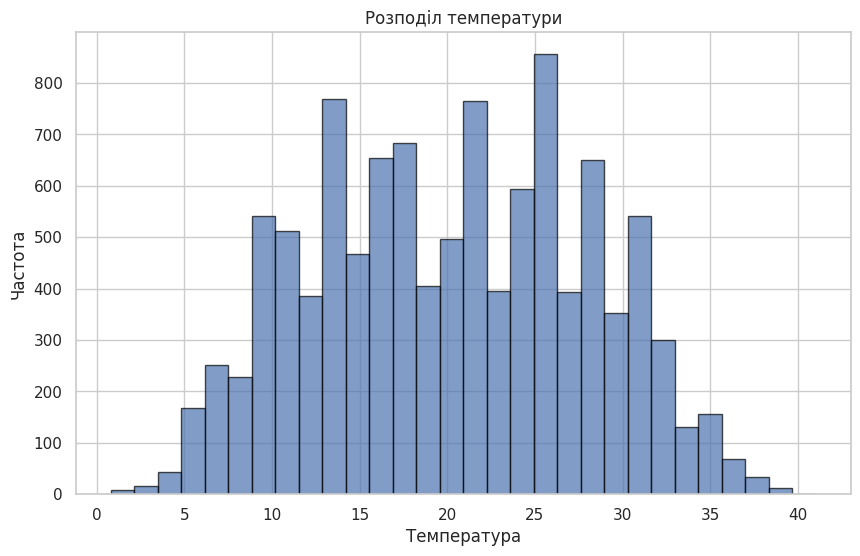

In [26]:
# Розподіл даних по температурі з Pandas
df['temp'].plot.hist(
    bins=30,
    figsize=(10, 6),
    alpha=0.7,
    edgecolor='black',
    title='Розподіл температури',
    xlabel='Температура',
    ylabel='Частота',
);

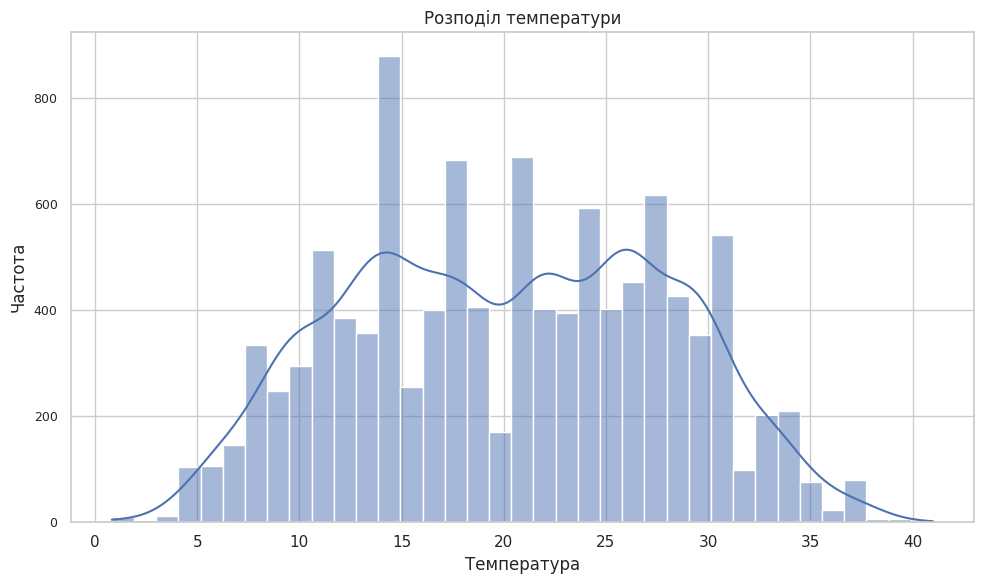

In [31]:
# Розподіл даних по температурі з Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(data=df,x='temp', kde=True)
plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Частота')
plt.yticks(fontsize=9)
plt.tight_layout();

**Відповіді на питання:**

1. Яка візуальна різниця між Pandas та Seaborn гістограмами?

- В Seaborn автоматично з'являється більше бінів, ніж в Pandas, тому в Pandas необхідно додатково вказувати кількість бінів в коді.
- Сам графік візуально більш приємніший для сприйняття в Seaborn, бо кожен стовпчик відокремлений, в Pandas всі стовпчики стоять плотно один до одного та виділяються чіткими контурами.

2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?
Це лінія, яка показує форму розподілу температури, тобто де температури зустрічаються частіше, а де рідше.


## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [34]:
df['weather_name'] = df['weather'].map({
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
})

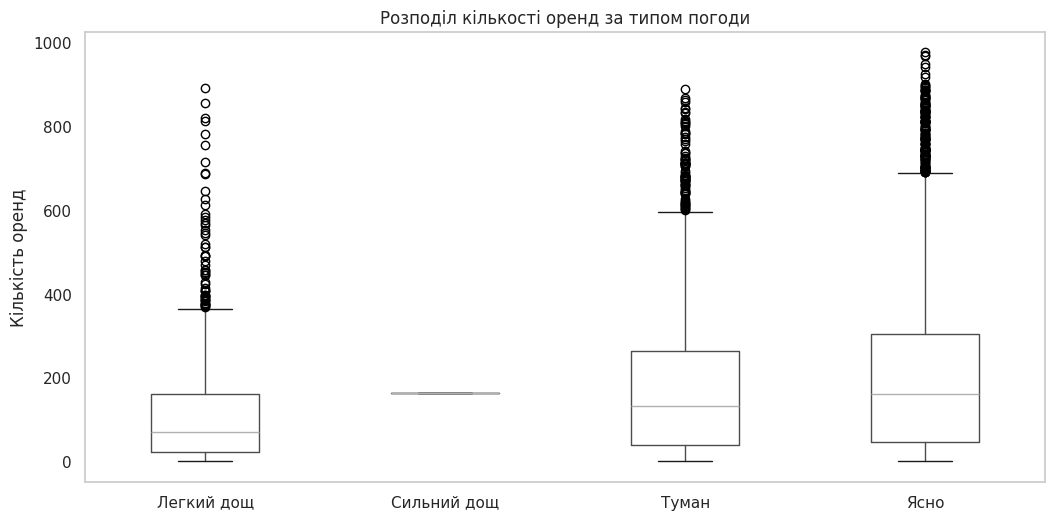

In [45]:
# box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas
df.boxplot(
    column='count',
    by='weather_name',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    figsize=(12, 6),
    grid = False,
)
plt.title('Розподіл кількості оренд за типом погоди')
plt.suptitle('')
plt.ylabel('Кількість оренд')
plt.xlabel('')
plt.show()

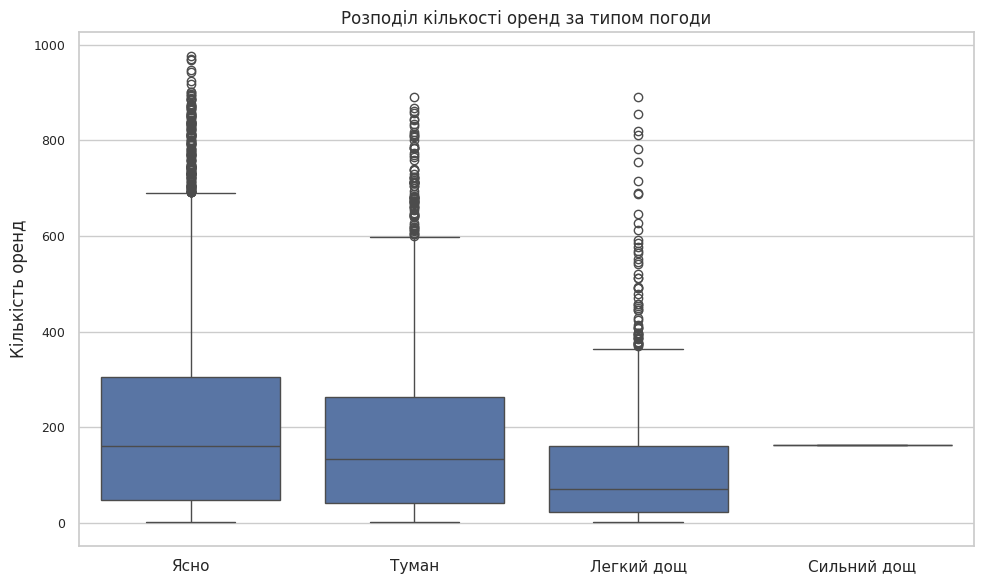

In [44]:
# box plot для кількості погодинних оренд велосипедів за погодними умовами з Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df,x='weather_name', y='count')
plt.title('Розподіл кількості оренд за типом погоди')
plt.xlabel('')
plt.ylabel('Кількість оренд')
plt.yticks(fontsize=9)
plt.tight_layout();

**Яка візуальна різниця між Pandas та Seaborn бокс-плотами?**

- В Pandas "коробки" выдобразилися за типом погоди в алфавітному порядку, а в Seaborn - за розміром "коробки", тобто за кількістю даних (від найбільшої до найменшої).
- В Pandas - коробки прозорі, а в Seaborn автоматично залиті синім кольором.


<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [47]:
correlation = df[['temp', 'atemp', 'count', 'humidity', 'windspeed']].corr()

In [48]:
correlation

,temp,atemp,count,humidity,windspeed
temp,1.000000,0.984948,0.394454,-0.064949,-0.017852
atemp,0.984948,1.000000,0.389784,-0.043536,-0.057473
count,0.394454,0.389784,1.000000,-0.317371,0.101369
humidity,-0.064949,-0.043536,-0.317371,1.000000,-0.318607
windspeed,-0.017852,-0.057473,0.101369,-0.318607,1.000000


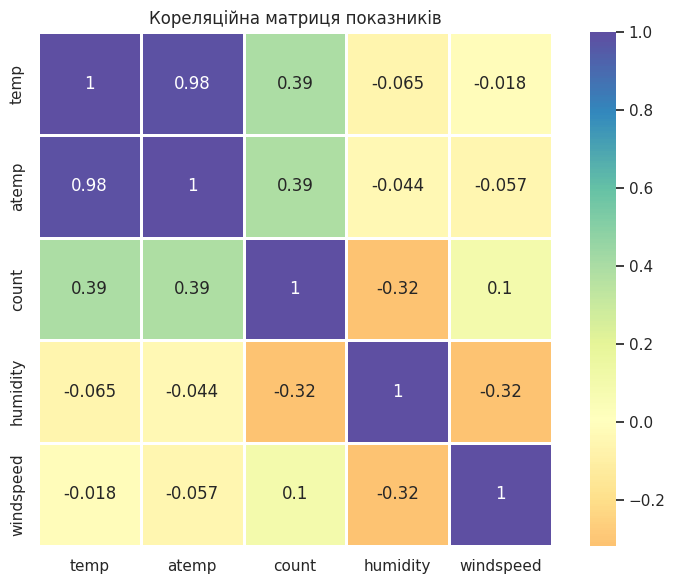

In [51]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='Spectral', center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

**Відповіді на питання по графіку:**

1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?

Змінні temp та atemp найсильніше корелюють з загальною кількістю оренди, тобто відбувається помірний позитивний зв'язок. Тобто, при підвищенні температури кількість оренд має тенденцію збільшуватися.

2. Яка кореляція між temp та atemp? Чому?

Кореляція між temp та atemp складає 0,98. Це означає, що зі зростанням фактичної температури практично пропорційно зростає і відчутна температура.

3. Які змінні мають негативну кореляцію?

Негативну кореляцію мають такі змінні: humidity + count, humidity + windspeed.
В першій парі змінних (humidity + count) означає, що зі збільшенням вологості кількість оренд має тенденцію зменшуватися, а в другій парі змінних (humidity + windspeed) означає, що при збільшенні вологості швидкість вітру в цьому наборі даних має тенденцію зменшуватися.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


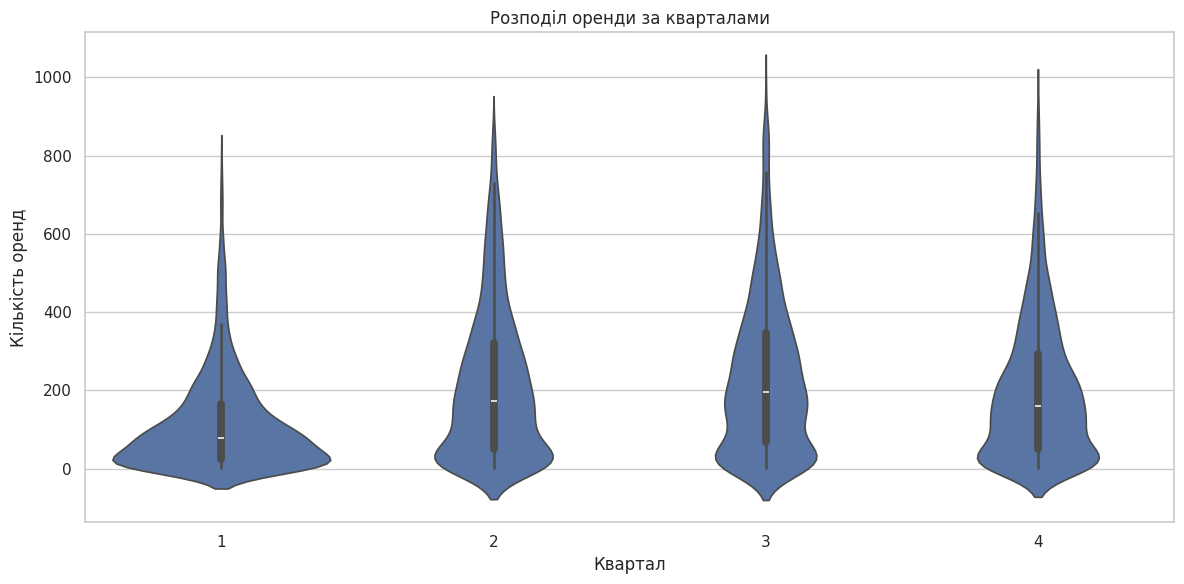

In [60]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='count',)
plt.title('Розподіл оренди за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

**Відповіді на питання:**

1. Що показує "товщина" violin plot?

Товщинана графіку в певному місці показує, наскільки часто зустрічаються значення в цьому діапазоні. Тобто чим ширше місце на  violin plot, тим частіше значень зустрічається в цьому діапазоні значень.

2. В якому кварталі найбільша варіабельність оренди?

Найбільша варіабельність оренди спостерігається в третьому кварталі, бо даний графік є найвищим, тобто від нижньої точки до верхньої точки розмах кількості оренд найбільший.

3. Яка перевага violin plot над звичайним box plot?

Violin plot показує не тільки основні статистичні характеристики, а й форму розподілу даних всередині категорії(кварталу), тобто як саме розподілені значення всередині діапазону графіка.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

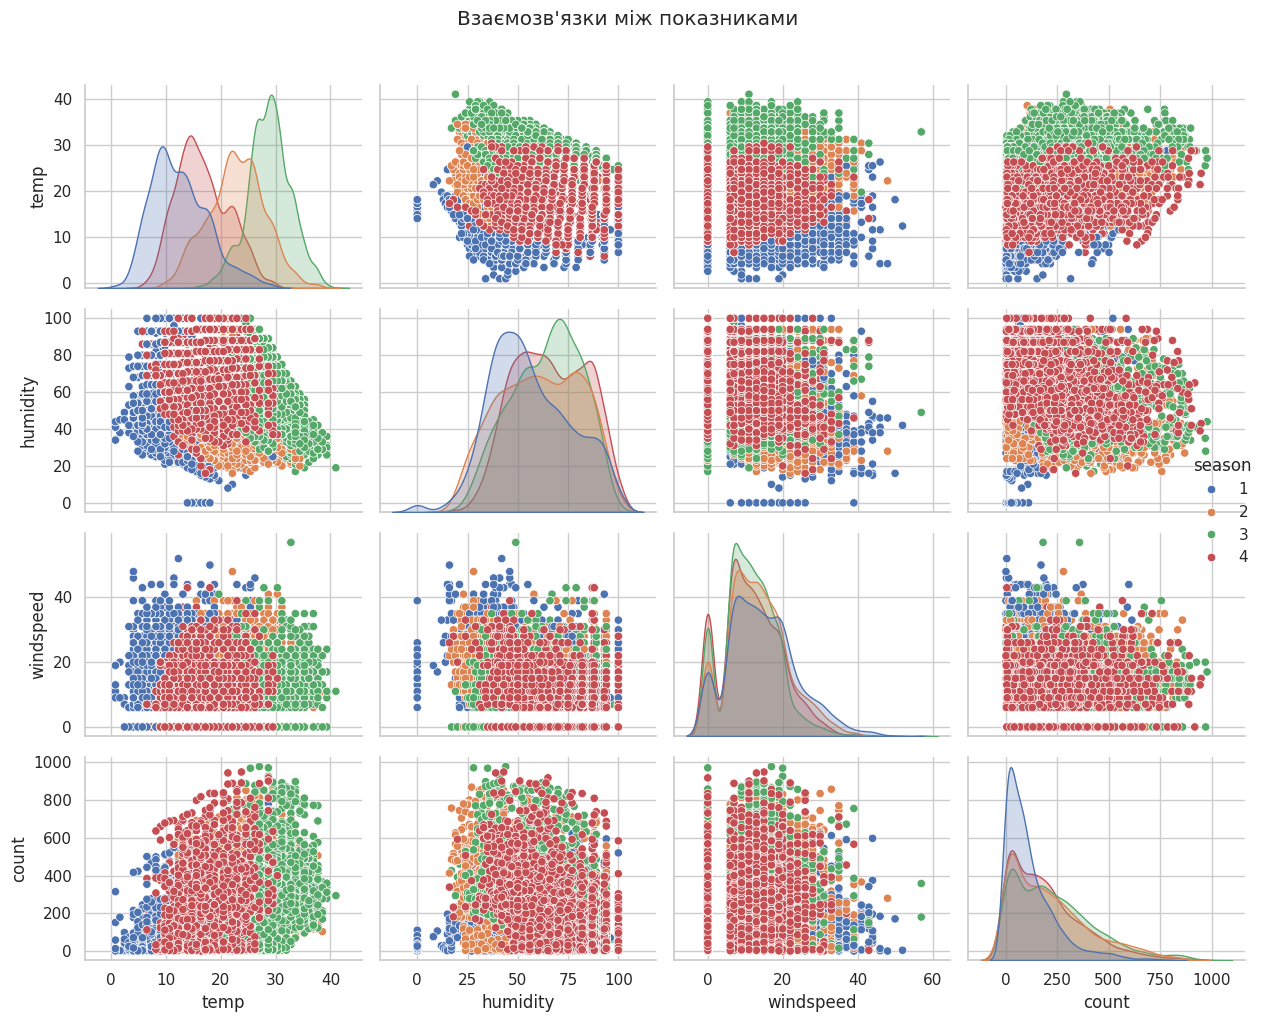

In [70]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]
sns.pairplot(sample_df, height=2.5, aspect=1.2, hue='season', palette='deep')
plt.suptitle('Взаємозв\'язки між показниками', y=1.02)
plt.tight_layout()
plt.show()

**Відповіді на питання:**

1. Між якими змінними спостерігається найсильніший лінійний зв'язок?

Найсильніший лінійний позитивний зв'язок спостерігається між температурою та кількістю. З підвищенням температури спостерігається помірне зростання кількості оренд.
Найсильніший лінійний негативний зв'язок спостерігається між вологістю та кількістю оренд. Тобто чим вища вологість повітря, тим кількість оренд помірно зменшується.

2. Яка характеристика найбільше відрізняється між кварталами?

Судячи з цієї парної діаграми, найбільше між квартали відрізняється температура (temp).

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

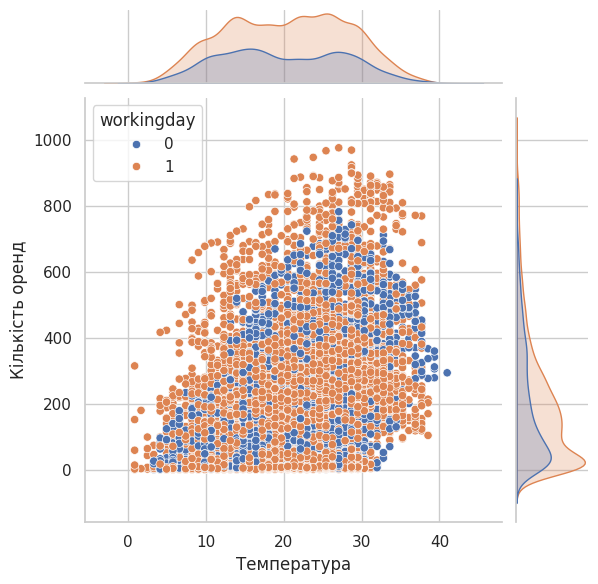

In [72]:
sns.jointplot(data=df, x="temp", y="count", hue="workingday")
plt.xlabel('Температура')
plt.ylabel('Кількість оренд');

**Відповіді на питання:**

1. Що показують графіки по краях?

Графіки по краях показують густину розподілу даних окремо по температурі та по кількості оренд з розбивкою по робочим та вихідним дням. Вони допомагають зрозуміти форму розподілу даних, не дивлячись на їх взаємозв'язок.

2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

За температурою розподіли схожі за формою, але помаранчева крива (робочі дні) вища, тому що робочих днів більше в даних. Форма розподілу температур не сильно залежить від типу дня — тобто люди їздять однаково в обидва типи днів.
Помаранчевих точок (робочі дні) більше на графіку та частина з них сягає вищих значень за сині точки (вихідні), що говорить про користування попитом на велосипеди в будні дні. Можна припустити, що багато людей регулярно їздять на роботу на цих велосипедах не дивлячись на температуру погоди.

In [76]:
workingdays_count = df.groupby('workingday')['count'].count()

In [77]:
workingdays_count

,count
workingday,
0,3474
1,7412
